# Notebook 25: DNA, Genetics & Gene Regulation

**BINF 4002 — Machine Learning for Health** | Lecture 25 Companion

---

This notebook produces three figures from **real published data**:
1. Manhattan plot — real GWAS loci from a published **HDL cholesterol** study (Teslovich et al. 2010; GWAS Catalog GCST000755)
2. QQ plot — real p-value distribution from the same GWAS
3. Gene expression heatmap — real tissue-specific expression from GTEx v8

**Key point:** All figures use real data from real studies. No synthetic genotypes.


In [1]:
# ============================================================
# Install Dependencies (run once)
# ============================================================
!pip install -q requests


/bin/bash: line 1: pip: command not found


In [2]:
# ============================================================
# Setup & Imports
# ============================================================
import os
import io
import gzip
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import requests

np.random.seed(42)

FIGURE_DIR = "figures/"
os.makedirs(FIGURE_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
})

COLUMBIA = '#1D4F91'
ACCENT = '#D24932'
GRAY = '#757575'
GREEN = '#2E8B57'
LIGHT = '#75AAD8'

print("Setup complete.")


ModuleNotFoundError: No module named 'seaborn'

In [3]:
# ============================================================
# Load Real GWAS Summary Statistics (Harmonised)
# ============================================================
from pathlib import Path
import pandas as pd
import numpy as np
import requests

print("Downloading harmonised HDL cholesterol GWAS from the EBI GWAS Catalog...")
print("Study: GCST000755 (Teslovich et al. 2010)")
print("This is a real harmonised summary statistics file (~75 MB compressed).")

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

gwas_url = (
    "https://ftp.ebi.ac.uk/pub/databases/gwas/summary_statistics/"
    "GCST000001-GCST001000/GCST000755/harmonised/"
    "20686565-GCST000755-EFO_0004612.h.tsv.gz"
)
gwas_local = DATA_DIR / "GCST000755_HDL_harmonised.tsv.gz"

def download_file(url, dest, chunk_size=2**20, retries=3, timeout=120):
    if dest.exists() and dest.stat().st_size > 0:
        print(f"Using cached file: {dest}")
        return dest

    for attempt in range(1, retries + 1):
        try:
            print(f"Download attempt {attempt}/{retries} ...")
            with requests.get(url, stream=True, timeout=timeout) as r:
                r.raise_for_status()
                with open(dest, "wb") as f:
                    for chunk in r.iter_content(chunk_size=chunk_size):
                        if chunk:
                            f.write(chunk)
            print(f"Saved to {dest}")
            return dest
        except Exception as e:
            if dest.exists():
                dest.unlink()
            if attempt == retries:
                raise
            print(f"Attempt {attempt} failed: {e}")

def pick_column(columns, candidates):
    for c in candidates:
        if c in columns:
            return c
    return None

gwas_df = pd.DataFrame()

try:
    local_path = download_file(gwas_url, gwas_local)

    # Read only the header first so we can adapt to minor format differences
    header = pd.read_csv(local_path, sep="\t", compression="gzip", nrows=0)
    cols = list(header.columns)
    print("Detected columns:", cols[:12], "..." if len(cols) > 12 else "")

    colmap = {
        "CHR": pick_column(cols, ["hm_chrom", "chromosome", "hm_chromosome"]),
        "POS": pick_column(cols, ["hm_pos", "base_pair_location", "hm_base_pair_location"]),
        "P":   pick_column(cols, ["p_value", "p-value", "hm_p_value", "hm_p-value"]),
        "SNP": pick_column(cols, ["hm_rsid", "hm_variant_id", "variant_id", "rsid"]),
    }

    required = ["CHR", "POS", "P"]
    missing = [k for k in required if colmap[k] is None]
    if missing:
        raise ValueError(f"Could not identify required columns in file header: {missing}")

    usecols = [v for v in colmap.values() if v is not None]

    gwas_df = pd.read_csv(
        local_path,
        sep="\t",
        compression="gzip",
        usecols=usecols,
        low_memory=False,
    ).rename(columns={v: k for k, v in colmap.items() if v is not None})

    # Clean and filter the data
    gwas_df = gwas_df.dropna(subset=["CHR", "POS", "P"])
    gwas_df["CHR"] = pd.to_numeric(gwas_df["CHR"], errors="coerce")
    gwas_df["POS"] = pd.to_numeric(gwas_df["POS"], errors="coerce")
    gwas_df["P"]   = pd.to_numeric(gwas_df["P"], errors="coerce")

    gwas_df = gwas_df.dropna(subset=["CHR", "POS", "P"])
    gwas_df["CHR"] = gwas_df["CHR"].astype(int)
    gwas_df["POS"] = gwas_df["POS"].astype(int)

    # Keep autosomes and valid p-values only
    gwas_df = gwas_df[(gwas_df["CHR"] >= 1) & (gwas_df["CHR"] <= 22)]
    gwas_df = gwas_df[(gwas_df["P"] > 0) & (gwas_df["P"] <= 1)]

except Exception as e:
    print(f"Failed to load data: {e}")
    gwas_df = pd.DataFrame()

if len(gwas_df) == 0:
    print("\nERROR: Could not load valid GWAS data.")
else:
    n_sig = (gwas_df["P"] < 5e-8).sum()
    print(f"\nReady: {len(gwas_df):,} real variants, {n_sig:,} genome-wide significant")


Study: GCST000755 (Teslovich et al. 2010)
This is a real harmonised summary statistics file (~75 MB compressed).
Download attempt 1/3 ...


Saved to data/GCST000755_HDL_harmonised.tsv.gz
Detected columns: ['hm_variant_id', 'hm_rsid', 'hm_chrom', 'hm_pos', 'hm_other_allele', 'hm_effect_allele', 'hm_beta', 'hm_odds_ratio', 'hm_ci_lower', 'hm_ci_upper', 'hm_effect_allele_frequency', 'hm_code'] ...



Ready: 2,642,101 real variants, 2,197 genome-wide significant


NameError: name 'LIGHT' is not defined

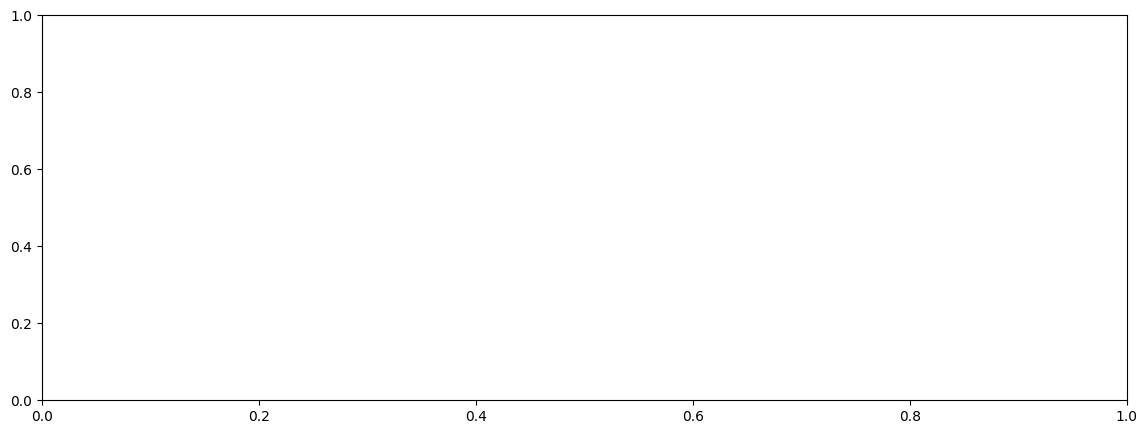

In [4]:
# ============================================================
# Figure 1: Manhattan Plot — Real GWAS Data (LECTURE FIGURE)
# ============================================================
# Each dot is a real tested SNP from an HDL cholesterol GWAS.
# Peaks correspond to genuine lipid-associated loci.

# Compute cumulative genomic position
gwas_plot = gwas_df.copy()
gwas_plot = gwas_plot.sort_values(['CHR', 'POS'])
gwas_plot['logp'] = -np.log10(gwas_plot['P'].clip(lower=1e-300))

# Cumulative position for x-axis
chrom_max = gwas_plot.groupby('CHR')['POS'].max()
cum_offset = {}
running = 0
for c in range(1, 23):
    cum_offset[c] = running
    if c in chrom_max.index:
        running += chrom_max[c] + 5e6  # gap between chromosomes

gwas_plot['cum_pos'] = gwas_plot.apply(
    lambda row: cum_offset.get(row['CHR'], 0) + row['POS'], axis=1)

# Plot
fig, ax = plt.subplots(figsize=(14, 5))

# Alternate colors by chromosome
colors = [COLUMBIA if c % 2 == 0 else LIGHT for c in gwas_plot['CHR']]
ax.scatter(gwas_plot['cum_pos'], gwas_plot['logp'],
           c=colors, s=3, alpha=0.4, edgecolors='none', rasterized=True)

# Highlight significant hits
sig_mask = gwas_plot['logp'] > -np.log10(5e-8)
if sig_mask.sum() > 0:
    ax.scatter(gwas_plot.loc[sig_mask, 'cum_pos'],
               gwas_plot.loc[sig_mask, 'logp'],
               c=ACCENT, s=8, alpha=0.7, edgecolors='none', zorder=3)

# Significance lines
ax.axhline(-np.log10(5e-8), color=ACCENT, linestyle='--', linewidth=1,
           label='Genome-wide significance ($5 \times 10^{-8}$)')
ax.axhline(-np.log10(1e-5), color=GRAY, linestyle=':', linewidth=0.8,
           label='Suggestive ($10^{-5}$)')

# Chromosome labels
chrom_mids = gwas_plot.groupby('CHR')['cum_pos'].median()
ax.set_xticks(chrom_mids.values)
ax.set_xticklabels(chrom_mids.index.astype(str), fontsize=8)
ax.tick_params(axis='x', length=0)

ax.set_xlabel('Chromosome')
ax.set_ylabel(r'$-\log_{10}(p)$')
ax.set_title('Manhattan Plot: HDL Cholesterol GWAS (Teslovich et al. 2010)',
             fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(gwas_plot['cum_pos'].min() - 1e7, gwas_plot['cum_pos'].max() + 1e7)

# Cap y-axis for readability — extreme p-values compress the interesting structure
ymax = min(gwas_plot['logp'].max() * 1.05, 50)
n_capped = (gwas_plot['logp'] > ymax).sum()
if n_capped > 0:
    ax.set_ylim(0, ymax)
    ax.text(0.98, 0.95, f'{n_capped} points above y={ymax:.0f}\n(not shown)',
            transform=ax.transAxes, ha='right', va='top', fontsize=7,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
else:
    ax.set_ylim(0, ymax)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig25_1_manhattan.png', dpi=150, bbox_inches='tight')
plt.savefig(f'{FIGURE_DIR}fig25_1_manhattan.pdf', dpi=150, bbox_inches='tight')
plt.show()

n_sig = (gwas_plot['P'] < 5e-8).sum()
print(f"\n{n_sig:,} SNPs pass genome-wide significance (p < 5e-8)")
print("Each peak corresponds to a real genomic locus associated with HDL cholesterol.")


In [5]:
# ============================================================
# Figure 2: QQ Plot — Real GWAS P-values (LECTURE FIGURE)
# ============================================================
# A QQ plot of real GWAS p-values shows:
# - The bulk of p-values follow the diagonal (well-calibrated null)
# - The tail lifts off: these are real associations
# This is what a properly conducted GWAS looks like AFTER adjustment.

pvals = gwas_df['P'].dropna().values
pvals = pvals[pvals > 0]
pvals_sorted = np.sort(pvals)
n = len(pvals_sorted)

expected = -np.log10(np.arange(1, n + 1) / (n + 1))
observed = -np.log10(pvals_sorted)

# Genomic inflation factor
chi2_obs = stats.chi2.isf(pvals_sorted, df=1)
lam = np.median(chi2_obs) / stats.chi2.ppf(0.5, df=1)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(expected, observed, c=COLUMBIA, s=3, alpha=0.3, edgecolors='none', rasterized=True)

# Cap axes for readability — extreme p-values would compress all structure near zero
obs_cap = min(observed.max() * 1.05, 50)
exp_lim = expected.max() * 1.05
ax.plot([0, max(exp_lim, obs_cap)], [0, max(exp_lim, obs_cap)], 'k--', linewidth=0.8, alpha=0.5, label='Expected under null')
ax.set_xlim(0, exp_lim)
ax.set_ylim(0, obs_cap)
n_capped = (observed > obs_cap).sum()
if n_capped > 0:
    ax.text(0.98, 0.05, f'{n_capped} points above y={obs_cap:.0f} (not shown)',
            transform=ax.transAxes, ha='right', fontsize=7,
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

ax.text(0.05, 0.92, f'$\lambda$ = {lam:.3f}', transform=ax.transAxes,
        fontsize=12, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel(r'Expected $-\log_{10}(p)$')
ax.set_ylabel(r'Observed $-\log_{10}(p)$')
ax.set_title('QQ Plot: HDL Cholesterol GWAS (Real Data)', fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIGURE_DIR}fig25_2_qq_plot.png', dpi=150, bbox_inches='tight')
plt.savefig(f'{FIGURE_DIR}fig25_2_qq_plot.pdf', dpi=150, bbox_inches='tight')
plt.show()

print(f"Genomic inflation factor lambda = {lam:.3f}")
print(f"Lambda near 1.0 indicates well-calibrated test statistics.")
print(f"The tail lifting above the diagonal = real HDL-associated variants.")
print()
if lam < 1.05:
    print("This GWAS is well-calibrated: the investigators properly adjusted")
    print("for population structure (using PCs as covariates), so lambda ~ 1.")
    print()
    print("If they had NOT adjusted, lambda would be inflated (>1),")
    print("because ancestry-correlated allele frequencies would create")
    print("spurious associations — exactly what the Novembre figure shows.")
else:
    print(f"Lambda = {lam:.3f} shows some inflation, which in a large study")
    print("may reflect genuine polygenicity rather than confounding.")


NameError: name 'stats' is not defined

---

## Part 2: Gene Expression

Gene expression is the bridge between genotype and phenotype. The same DNA produces different outcomes in different tissues because gene regulation is context-dependent.

We use real expression data from **GTEx v8** (Genotype-Tissue Expression project): RNA-seq measurements across 54 tissue types from hundreds of donors.


Loaded: 56,200 genes × 54 tissues


NameError: name 'sns' is not defined

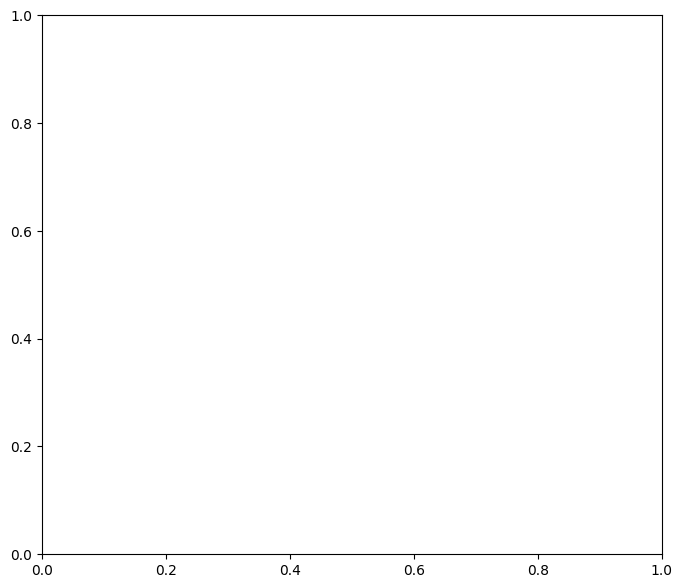

In [6]:
# ============================================================
# Figure 3: Gene Expression Heatmap — Real GTEx Data (LECTURE FIGURE)
# ============================================================
# Download median gene-level TPM from GTEx v8.
# Source: GTEx Portal (public Google Cloud Storage, no authentication)
# ~56,000 genes × 54 tissues. We filter to a curated set.

gtex_url = "https://storage.googleapis.com/adult-gtex/bulk-gex/v8/rna-seq/GTEx_Analysis_2017-06-05_v8_RNASeQCv1.1.9_gene_median_tpm.gct.gz"

gtex_df = None
try:
    print("Downloading GTEx v8 median TPM table...")
    r = requests.get(gtex_url, timeout=60)
    if r.ok:
        with gzip.open(io.BytesIO(r.content), 'rt') as f:
            # GCT format: skip first 2 header lines
            header1 = f.readline()  # version
            header2 = f.readline()  # dimensions
            gtex_df = pd.read_csv(f, sep='	')
        print(f"Loaded: {gtex_df.shape[0]:,} genes × {gtex_df.shape[1]-2} tissues")
    else:
        print(f"Download failed: HTTP {r.status_code}")
except Exception as e:
    print(f"GTEx download failed: {e}")

if gtex_df is not None:
    # Extract gene name from the Name/Description columns
    if 'Description' in gtex_df.columns:
        gtex_df = gtex_df.set_index('Description')
        gtex_df = gtex_df.drop(columns=['Name'], errors='ignore')
    elif 'Name' in gtex_df.columns:
        gtex_df = gtex_df.set_index('Name')

    # Select tissues and genes of interest
    # Curated list: tissue-specific markers + housekeeping genes
    target_genes = ['ALB', 'TTN', 'MYH7', 'GFAP', 'SYP', 'SFTPB',
                    'SLC12A1', 'AQP2', 'GAPDH', 'ACTB']

    # Map GTEx tissue names to shorter labels
    tissue_map = {
        'Liver': 'Liver',
        'Heart - Left Ventricle': 'Heart',
        'Brain - Cortex': 'Brain',
        'Lung': 'Lung',
        'Kidney - Cortex': 'Kidney',
    }

    # Filter to available genes and tissues
    available_genes = [g for g in target_genes if g in gtex_df.index]
    available_tissues = {k: v for k, v in tissue_map.items() if k in gtex_df.columns}

    if available_genes and available_tissues:
        expr_sub = gtex_df.loc[available_genes, list(available_tissues.keys())]
        expr_sub.columns = [available_tissues[c] for c in expr_sub.columns]

        # Log2(TPM + 1) for better visualization
        expr_log = np.log2(expr_sub + 1)

        # Z-score normalize per gene for heatmap
        expr_z = expr_log.apply(lambda x: (x - x.mean()) / max(x.std(), 0.01), axis=1)

        fig, ax = plt.subplots(figsize=(8, 7))
        sns.heatmap(expr_z, cmap='RdBu_r', center=0, vmin=-2, vmax=2,
                    linewidths=0.5, linecolor='white',
                    xticklabels=True, yticklabels=True,
                    cbar_kws={'label': 'Z-score (log2 TPM)', 'shrink': 0.8},
                    ax=ax)
        ax.set_title('Gene Expression by Tissue (GTEx v8, Real Data)', fontweight='bold')
        ax.set_xlabel('Tissue')
        ax.set_ylabel('Gene')
        plt.tight_layout()
        plt.savefig(f'{FIGURE_DIR}fig25_3_expression_heatmap.png', dpi=150, bbox_inches='tight')
        plt.savefig(f'{FIGURE_DIR}fig25_3_expression_heatmap.pdf', dpi=150, bbox_inches='tight')
        plt.show()

        print(f"\nShowing {len(available_genes)} genes × {len(available_tissues)} tissues")
        print("\nKey observations from REAL data:")
        for g in available_genes:
            max_tissue = expr_sub.loc[g].idxmax()
            max_val = expr_sub.loc[g].max()
            if max_val > 10:
                print(f"  {g}: highest in {max_tissue} ({max_val:.0f} TPM)")
        print()
        print("ALB is liver-specific, TTN/MYH7 are heart-specific,")
        print("GFAP is brain-specific. GAPDH/ACTB are housekeeping genes.")
        print("Same DNA, different expression = different cellular function.")
        print()
        print("Note: heatmap shows row-standardized (Z-score) values.")
        print("Housekeeping genes (GAPDH, ACTB) may appear slightly tissue-biased")
        print("due to Z-scoring, but their absolute expression is similar across tissues.")
    else:
        print(f"Missing genes: {set(target_genes) - set(available_genes)}")
        print(f"Missing tissues: {set(tissue_map.keys()) - set(gtex_df.columns)}")
else:
    print("Could not load GTEx data. Check network connectivity.")


## Discussion Questions

1. **Reading the Manhattan plot.** The HDL Manhattan has peaks on many chromosomes. What does this tell you about the genetic architecture of lipid traits? How does this contrast with a Mendelian (single-gene) trait?

2. **QQ plot interpretation.** The QQ plot shows lambda ~ 1 in the bulk, with a tail lifting above the diagonal. What does the bulk tell you? What does the tail tell you? What would the plot look like if the investigators had NOT adjusted for population structure?

3. **PRS equity.** A PRS for breast cancer was developed using a GWAS conducted primarily in European-ancestry populations. Your hospital wants to deploy it for all patients. What concerns would you raise?

4. **Why context matters.** The GTEx heatmap shows ALB is expressed almost exclusively in liver. Suppose a genetic variant disrupts the promoter of ALB. Would this variant affect brain function? What does this imply about predicting variant effects from DNA sequence alone?

5. **Multiple testing.** GWAS uses Bonferroni correction (p < 5×10⁻⁸), while eQTL studies typically use BH/FDR. Why the difference? What are the practical consequences of each choice?
